# Shots Convergence Experiment

How does the number of measurement shots affect the estimate quality of the W-state?

**Design:**
- Qubit sizes N ∈ {5, 10, 20}
- Shot counts ∈ {200, 500, 2000, 4000}
- 3 independent repetitions per (N, shots) pair
- Metrics: Z-basis fidelity, X-basis entanglement witness ⟨W⟩
- Routing: swap-free best-chain (same beam search as the main notebook)

In [12]:
# ── Experiment parameters ──────────────────────────────────────────────────
QUBIT_SIZES  = [5, 10, 20]
SHOT_COUNTS  = [200, 500, 2000, 4000]
N_REPS       = 3
BEAM_WIDTH   = 100

## 1. Connect to IQM Resonance

In [13]:
import os
from pathlib import Path
from iqm.qiskit_iqm import IQMProvider

secret_path = Path().cwd() / ".secrets" / "iqm_api_key"
api_token = secret_path.read_text().strip() if secret_path.exists() \
            else input("IQM Resonance API token: ").strip()
os.environ["IQM_TOKEN"] = api_token

provider = IQMProvider("https://resonance.meetiqm.com", quantum_computer="emerald")
backend  = provider.get_backend()
print(f"Connected to: {backend.name}  ({backend.num_qubits} qubits)")

Connected to: IQMBackend  (54 qubits)


## 2. Load calibration data

In [14]:
import numpy as np
from iqm.qubit_selector.qubit_selector import CalibrationDataManager

cal = CalibrationDataManager().get_calibration_fidelities(backend)

cz_raw      = cal.get("CZ", {})
readout_raw = cal.get("readout", {})
t1_raw      = cal.get("t1", {})
t2_raw      = cal.get("t2", {})

def _parse_pair(fid_dict):
    out = {}
    for k, v in fid_dict.items():
        try:
            names = eval(k)
            idxs  = tuple(backend.qubit_name_to_index(n) for n in names)
            out[frozenset(idxs)] = float(v)
        except Exception:
            pass
    return out

def _parse_qubit(raw):
    out = {}
    for name, v in raw.items():
        try:
            out[backend.qubit_name_to_index(name)] = float(v)
        except Exception:
            pass
    return out

cz_fid  = _parse_pair(cz_raw)
ro_fid  = _parse_qubit(readout_raw)
t1_us   = _parse_qubit(t1_raw)
t2_us   = _parse_qubit(t2_raw)

cz_durations = []
if "cz" in backend.target:
    for qargs, props in backend.target["cz"].items():
        if props and props.duration:
            cz_durations.append(props.duration)
mean_cz_ns = np.mean(cz_durations) * 1e9 if cz_durations else 80.0

def t1_survival(phys, wait_ns, default_t1_us=200.0):
    t1_ns = t1_us.get(phys, default_t1_us) * 1e3
    return float(np.exp(-wait_ns / t1_ns))

def t2_survival(phys, wait_ns, default_t2_us=100.0):
    t2_ns = t2_us.get(phys, default_t2_us) * 1e3
    return float(np.exp(-wait_ns / t2_ns))

print(f"CZ fidelities: {len(cz_fid)} edges | Readout: {len(ro_fid)} qubits")
print(f"Mean CZ gate duration: {mean_cz_ns:.1f} ns")

CZ fidelities: 81 edges | Readout: 54 qubits
Mean CZ gate duration: 80.0 ns


## 3. Build topology + beam search helpers

In [15]:
import math
import networkx as nx

# Build adjacency from coupling map
edges_list = list(backend.coupling_map.get_edges())
adj = {}
for u, v in edges_list:
    adj.setdefault(u, set()).add(v)
    adj.setdefault(v, set()).add(u)

def beam_search_chain(n, adj, cz_fid, ro_fid, t1_fn, t2_fn,
                      gate_ns, beam_width,
                      default_cz=0.90, default_ro=0.95):
    def log_s(x):
        return math.log(max(x, 1e-12))

    beam = [(log_s(ro_fid.get(q, default_ro))
             + log_s(t1_fn(q, (n-1)*3*gate_ns))
             + log_s(t2_fn(q, (n-1)*3*gate_ns)),
             [q])
            for q in adj]
    beam.sort(reverse=True)
    beam = beam[:beam_width]

    for step in range(n - 1):
        pos     = step + 1
        wait_ns = (n - 1 - pos) * 3 * gate_ns
        candidates = []
        for log_score, path in beam:
            last = path[-1]; used = set(path)
            for nbr in adj[last]:
                if nbr in used:
                    continue
                new_log = (log_score
                           + log_s(cz_fid.get(frozenset((last, nbr)), default_cz))
                           + log_s(ro_fid.get(nbr, default_ro))
                           + log_s(t1_fn(nbr, wait_ns))
                           + log_s(t2_fn(nbr, wait_ns)))
                candidates.append((new_log, path + [nbr]))
        if not candidates:
            break
        candidates.sort(reverse=True)
        beam = candidates[:beam_width]

    complete = [(s, p) for s, p in beam if len(p) == n]
    if not complete:
        raise RuntimeError(f"No complete chain of length {n} found")
    best_log, best_path = complete[0]
    return best_path, math.exp(best_log)


def parse_counts(raw_counts, n_qubits):
    """IQM returns space-separated bitstrings; take the last (projective) register."""
    out = {}
    for bs, cnt in raw_counts.items():
        parts = bs.strip().split()
        key = parts[-1][-n_qubits:]
        out[key] = out.get(key, 0) + cnt
    return out


def z_fidelity(counts, n_qubits):
    """Fraction of counts that are valid single-excitation W-state bitstrings."""
    total = sum(counts.values())
    w_bitstrings = {format(1 << i, f'0{n_qubits}b') for i in range(n_qubits)}
    return sum(counts.get(s, 0) for s in w_bitstrings) / total if total else 0.0


def x_witness(counts, n_qubits):
    """Mean off-diagonal X-basis correlator — entanglement witness ⟨W⟩."""
    total = sum(counts.values())
    probs = {k: v / total for k, v in counts.items()}

    def corr(i, j):
        return sum(
            (1 - 2 * int(b[-(i + 1)])) * (1 - 2 * int(b[-(j + 1)])) * p
            for b, p in probs.items()
        )

    vals = [corr(i, j) for i in range(n_qubits) for j in range(i + 1, n_qubits)]
    return float(np.mean(vals)) if vals else 0.0


print("Helpers defined.")

Helpers defined.


## 4. Find best chain for each qubit size and transpile circuits

In [16]:
from qiskit import transpile
from iqm.qubit_selector.qiskit_utils import get_circuit, CircuitType

# chains[n] = best_chain (list of physical qubit indices)
# circuits[n] = (qc_z_transpiled, qc_x_transpiled)
chains   = {}
circuits = {}

for n in QUBIT_SIZES:
    print(f"\n── N={n} ──────────────────────────────")
    chain, score = beam_search_chain(
        n, adj, cz_fid, ro_fid,
        t1_fn=t1_survival, t2_fn=t2_survival,
        gate_ns=mean_cz_ns, beam_width=BEAM_WIDTH
    )
    chains[n] = chain
    names = [backend.index_to_qubit_name(q) for q in chain]
    print(f"  Chain: {' → '.join(names)}")
    print(f"  Score: {score:.4e}")

    qc_z = get_circuit(CircuitType.WSTATE, n); qc_z.measure_all()
    qc_x = get_circuit(CircuitType.WSTATE, n)
    qc_x.h(range(n)); qc_x.measure_all()

    qc_z_t = transpile(qc_z, backend=backend, initial_layout=chain,
                       routing_method="none", optimization_level=1)
    qc_x_t = transpile(qc_x, backend=backend, initial_layout=chain,
                       routing_method="none", optimization_level=1)

    assert qc_z_t.count_ops().get("swap", 0) == 0
    assert qc_x_t.count_ops().get("swap", 0) == 0
    circuits[n] = (qc_z_t, qc_x_t)
    print(f"  Depth Z/X: {qc_z_t.depth()} / {qc_x_t.depth()}  |  SWAPs: 0 ✓")

print("\nAll circuits ready.")


── N=5 ──────────────────────────────
  Chain: QB11 → QB12 → QB6 → QB2 → QB1
  Score: 8.5022e-01
  Depth Z/X: 14 / 15  |  SWAPs: 0 ✓

── N=10 ──────────────────────────────
  Chain: QB12 → QB11 → QB5 → QB1 → QB2 → QB6 → QB7 → QB13 → QB14 → QB22
  Score: 5.2760e-01
  Depth Z/X: 24 / 25  |  SWAPs: 0 ✓

── N=20 ──────────────────────────────
  Chain: QB12 → QB11 → QB5 → QB1 → QB2 → QB6 → QB7 → QB13 → QB14 → QB22 → QB30 → QB29 → QB37 → QB45 → QB51 → QB50 → QB44 → QB36 → QB35 → QB34
  Score: 8.2181e-02
  Depth Z/X: 44 / 45  |  SWAPs: 0 ✓

All circuits ready.


## 5. Submit all jobs

For each (N, shots, rep) pair we submit both Z-basis and X-basis circuits.  
All jobs are submitted first to minimise wall-clock time, then retrieved in order.

In [17]:
# job_registry: keys are (n, shots, rep), values are (job_z, job_x)
job_registry = {}
total_jobs = 0

for n in QUBIT_SIZES:
    qc_z_t, qc_x_t = circuits[n]
    for shots in SHOT_COUNTS:
        for rep in range(N_REPS):
            job_z = backend.run(qc_z_t, shots=shots)
            job_x = backend.run(qc_x_t, shots=shots)
            job_registry[(n, shots, rep)] = (job_z, job_x)
            total_jobs += 2
            print(f"  N={n:2d} | shots={shots:4d} | rep={rep} → "
                  f"Z:{job_z.job_id()[:8]}…  X:{job_x.job_id()[:8]}…")

print(f"\nSubmitted {total_jobs} jobs total.")

  N= 5 | shots= 200 | rep=0 → Z:019e0dd0…  X:019e0dd0…


KeyboardInterrupt: 

## 6. Retrieve results and compute metrics

In [ ]:
# results[n][shots] = list of {fidelity_z, witness_x} over reps
results = {n: {s: [] for s in SHOT_COUNTS} for n in QUBIT_SIZES}

for (n, shots, rep), (job_z, job_x) in job_registry.items():
    print(f"Fetching N={n} shots={shots} rep={rep} ...", end=" ")
    counts_z = parse_counts(job_z.result().get_counts(), n)
    counts_x = parse_counts(job_x.result().get_counts(), n)
    fz = z_fidelity(counts_z, n)
    wx = x_witness(counts_x, n)
    results[n][shots].append({"fidelity_z": fz, "witness_x": wx})
    print(f"fid={fz:.3f}  W={wx:.4f}")

print("\nAll results collected.")

Fetching N=5 shots=200 rep=0 ... [05-09 18:38:00;I] Waiting for job 019e0d99-8a3a-7bb1-9e38-1648df51e3d2 to finish...
[05-09 18:38:01;I] Waiting for job 019e0d99-8cc3-7a51-86c0-22460db6d2da to finish...
fid=0.895  W=0.2320
Fetching N=5 shots=200 rep=1 ... [05-09 18:38:03;I] Waiting for job 019e0d99-8f83-7472-bae4-224153e8af24 to finish...
[05-09 18:38:04;I] Waiting for job 019e0d99-92b0-7071-a70f-4c25566514ec to finish...
fid=0.905  W=0.2540
Fetching N=5 shots=200 rep=2 ... [05-09 18:38:05;I] Waiting for job 019e0d99-95a8-7853-8713-ca2515b45403 to finish...
[05-09 18:38:07;I] Waiting for job 019e0d99-9886-7e92-9b3e-4a6b957cf6d2 to finish...
fid=0.925  W=0.2340
Fetching N=5 shots=500 rep=0 ... [05-09 18:38:08;I] Waiting for job 019e0d99-9b4d-79a1-92e7-570f9be8f7e1 to finish...
[05-09 18:38:10;I] Waiting for job 019e0d99-9e01-7971-9d34-f6ea82821c44 to finish...
fid=0.922  W=0.2504
Fetching N=5 shots=500 rep=1 ... [05-09 18:38:11;I] Waiting for job 019e0d99-a0f4-7ed2-806e-2265dfac40bf to 

## 7. Plot convergence

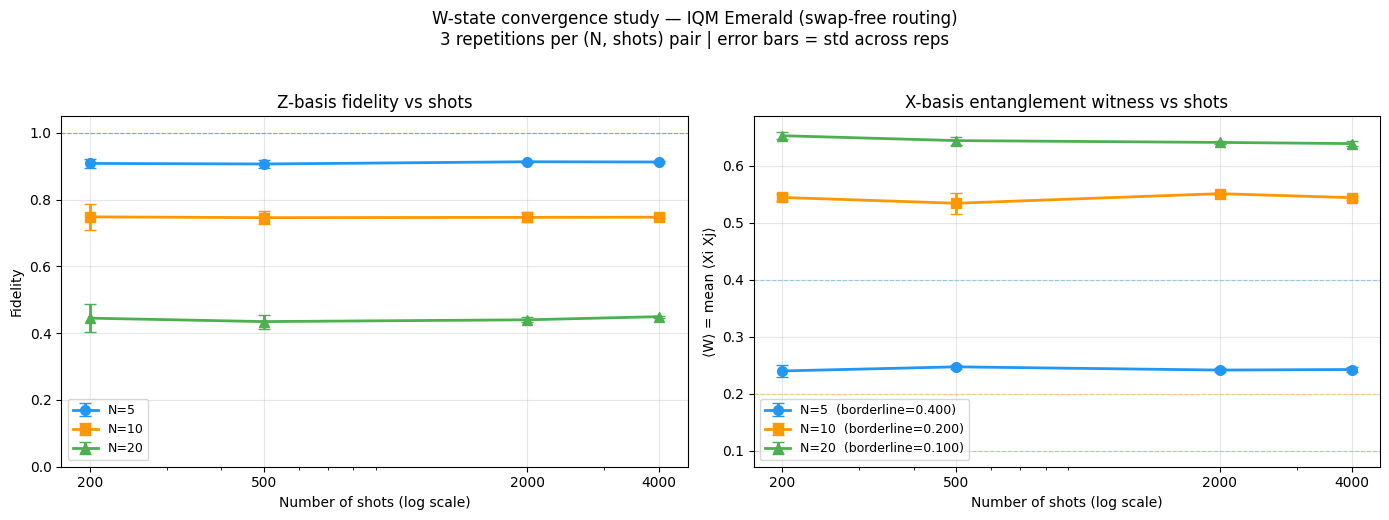

Saved: shots_convergence.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

colors = {5: "#2196F3", 10: "#FF9800", 20: "#4CAF50"}
markers = {5: "o", 10: "s", 20: "^"}  # circle, square, triangle

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_z, ax_x = axes

for n in QUBIT_SIZES:
    ideal_z = 1.0          # ideal Z-fidelity
    borderline_x = 2.0 / n     # borderline X witness

    fz_means, fz_stds = [], []
    wx_means, wx_stds = [], []

    for shots in SHOT_COUNTS:
        reps_data = results[n][shots]
        fzs = [r["fidelity_z"] for r in reps_data]
        wxs = [r["witness_x"]  for r in reps_data]
        fz_means.append(np.mean(fzs))
        fz_stds.append(np.std(fzs))
        wx_means.append(np.mean(wxs))
        wx_stds.append(np.std(wxs))

    ax_z.errorbar(
        SHOT_COUNTS, fz_means, yerr=fz_stds,
        label=f"N={n}",
        color=colors[n], marker=markers[n],
        capsize=4, linewidth=2, markersize=7
    )
    ax_z.axhline(ideal_z, color=colors[n], lw=0.8, ls="--", alpha=0.4)

    ax_x.errorbar(
        SHOT_COUNTS, wx_means, yerr=wx_stds,
        label=f"N={n}  (borderline={borderline_x:.3f})",
        color=colors[n], marker=markers[n],
        capsize=4, linewidth=2, markersize=7
    )
    ax_x.axhline(borderline_x, color=colors[n], lw=0.8, ls="--", alpha=0.4)

for ax, title, ylabel in [
    (ax_z, "Z-basis fidelity vs shots", "Fidelity"),
    (ax_x, "X-basis entanglement witness vs shots", "⟨W⟩ = mean ⟨Xi Xj⟩"),
]:
    ax.set_xscale("log")
    ax.set_xticks(SHOT_COUNTS)
    ax.set_xticklabels([str(s) for s in SHOT_COUNTS])
    ax.set_xlabel("Number of shots (log scale)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

ax_z.set_ylim(0, 1.05)

plt.suptitle(
    f"W-state convergence study — IQM Emerald (swap-free routing)\n"
    f"{N_REPS} repetitions per (N, shots) pair | error bars = std across reps",
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig("shots_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shots_convergence.png")

## 8. Summary table

In [ ]:
print(f"{'N':>4} {'shots':>6} {'fid_z mean':>11} {'fid_z std':>10} {'W mean':>9} {'W std':>8} {'borderline W':>8}")
print("-" * 65)
for n in QUBIT_SIZES:
    borderline_x = 2.0 / n
    for shots in SHOT_COUNTS:
        reps_data = results[n][shots]
        fzs = [r["fidelity_z"] for r in reps_data]
        wxs = [r["witness_x"]  for r in reps_data]
        print(f"{n:>4} {shots:>6} {np.mean(fzs):>11.4f} {np.std(fzs):>10.4f} "
              f"{np.mean(wxs):>9.4f} {np.std(wxs):>8.4f} {borderline_x:>8.4f}")

   N  shots  fid_z mean  fid_z std    W mean    W std borderline W
-----------------------------------------------------------------
   5    200      0.9083     0.0125    0.2400   0.0099   0.4000
   5    500      0.9067     0.0123    0.2472   0.0035   0.4000
   5   2000      0.9133     0.0027    0.2415   0.0033   0.4000
   5   4000      0.9127     0.0041    0.2425   0.0045   0.4000
  10    200      0.7483     0.0386    0.5442   0.0069   0.2000
  10    500      0.7460     0.0185    0.5341   0.0181   0.2000
  10   2000      0.7468     0.0153    0.5509   0.0018   0.2000
  10   4000      0.7473     0.0028    0.5438   0.0036   0.2000
  20    200      0.4450     0.0414    0.6525   0.0064   0.1000
  20    500      0.4347     0.0210    0.6439   0.0070   0.1000
  20   2000      0.4400     0.0071    0.6407   0.0033   0.1000
  20   4000      0.4495     0.0034    0.6387   0.0039   0.1000
